In [1]:
print("done")

done


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

# Base directory where the dataset is mounted
base_dir = "/kaggle/input/sicapv2"

# Check directory structure
for root, dirs, files in os.walk(base_dir):
    print(f"{root} -> {len(files)} files")



/kaggle/input/sicapv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2 -> 2 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/images -> 18783 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val3 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val4 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val2 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val1 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Test -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks -> 18783 files


In [3]:
import os

image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
print("Files in images dir:", os.listdir(image_dir)[:5])


Files in images dir: ['16B0006669_Block_Region_24_6_2_xini_14275_yini_13598.jpg', '18B0005230E_Block_Region_5_11_23_xini_38257_yini_96363.jpg', '18B0006621D_Block_Region_2_1_13_xini_21582_yini_66086.jpg', '18B0006177A_Block_Region_2_6_19_xini_51693_yini_147491.jpg', '16B0022612_Block_Region_1_20_12_xini_15667_yini_92428.jpg']


Total images found: 18783
✅ Found matching image + mask for: 17B0024162_Block_Region_4_14_10_xini_26177_yini_50778.jpg
Image shape: (512, 512, 3)
Mask shape: (512, 512)
Unique values in mask: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  36  40  42
  67  68  73  74  76  77  79  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 122 159 163 164 168 169 171 172
 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190
 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208
 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 227
 228 229 230 231 233 235]


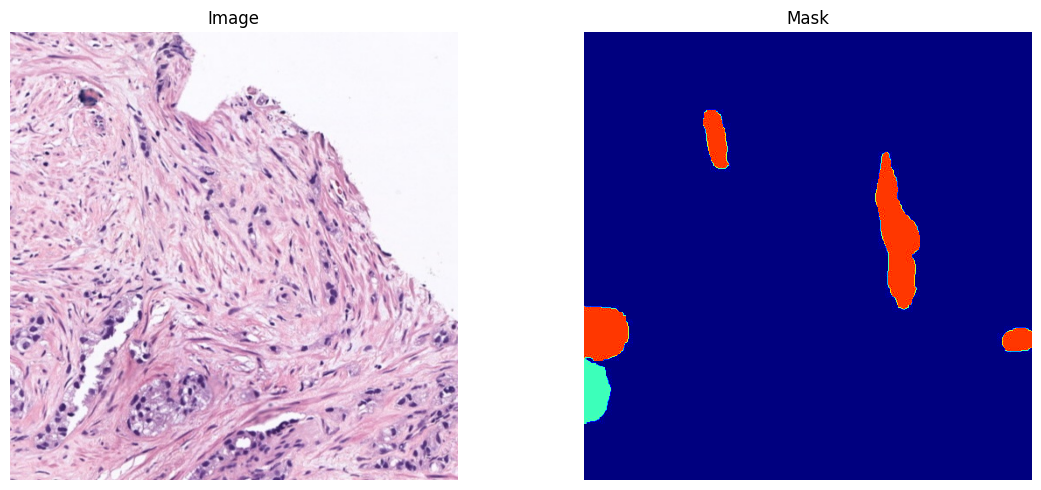

In [4]:
import random
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

# Correct image and mask directories
image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
mask_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks"

# Get list of image files
image_paths = glob(os.path.join(image_dir, "*.jpg"))
print(f"Total images found: {len(image_paths)}")

# Try loading image-mask pair
for _ in range(20):
    sample_image_path = random.choice(image_paths)
    filename = os.path.basename(sample_image_path)
    sample_mask_path = os.path.join(mask_dir, filename)  # No extension change now

    if os.path.exists(sample_mask_path):
        print("✅ Found matching image + mask for:", filename)
        break
else:
    raise FileNotFoundError("No matching masks found for any image.")

# Load image and mask
image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# Print some sanity info
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Unique values in mask:", np.unique(mask))

# Show image and mask
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='jet')
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()



In [5]:
import pandas as pd

# Path to Excel label file
xlsx_path = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx"

# Read Excel
df = pd.read_excel(xlsx_path)

# Your GG logic
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"

df["GG"] = df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

print(df.head())
print(df["GG"].value_counts())


     slide_id  patient_id  Gleason_primary  Gleason_secondary   GG
0  16B0001851      667360                4                  5  GG5
1  16B0003388      325687                4                  4  GG4
2  16B0003394      747184                3                  3   NC
3  16B0006668       14107                5                  5  GG5
4  16B0006669       14107                5                  5  GG5
GG
NC     72
GG5    42
GG3    23
GG4    18
Name: count, dtype: int64


In [6]:
from glob import glob
import pandas as pd
import os

# Load GG labels
labels_df = pd.read_excel("/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx")
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"
labels_df["GG"] = labels_df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

# Create a dictionary for quick lookup
slideid_to_gg = dict(zip(labels_df["slide_id"].astype(str), labels_df["GG"]))

# Grab all patch image paths
patch_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
patch_paths = glob(os.path.join(patch_dir, "*.jpg"))

# Build dataframe with patch paths and labels
patch_data = []
for path in patch_paths:
    filename = os.path.basename(path)
    slide_id = filename.split("_")[0]
    if slide_id in slideid_to_gg:
        label = slideid_to_gg[slide_id]
        patch_data.append((path, label))

# Create final dataframe
patch_df = pd.DataFrame(patch_data, columns=["path", "label"])
print("Total labeled patches:", len(patch_df))
print(patch_df["label"].value_counts())
patch_df.head()


Total labeled patches: 18783
label
NC     7995
GG5    5654
GG3    3082
GG4    2052
Name: count, dtype: int64


,path,label
0,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
1,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC
2,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG3
3,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
4,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC


In [7]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [8]:
from sklearn.model_selection import train_test_split

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    patch_df, test_size=0.2, stratify=patch_df["label"], random_state=42)

# Second split: val vs test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 15026 | Val: 1878 | Test: 1879


In [9]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [10]:
#  imports, device, DenseNet-169 backbone, ECA module, and feature extraction helper
import os
import math
import random
import numpy as np
from glob import glob
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import densenet169, DenseNet169_Weights

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- DenseNet-169 backbone ----------------
# Load pretrained DenseNet-169 (torchvision)
densenet = densenet169(weights=DenseNet169_Weights.IMAGENET1K_V1)
densenet = densenet.to(device)
densenet.eval()
print("DenseNet-169 loaded.")

# ---------------- Efficient Channel Attention (ECA) ----------------
# ECA: https://arxiv.org/abs/1910.03151
# Implementation: adaptive 1D conv on channel-wise averaged features.
class ECA(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        """
        channels: number of channels of the input feature map
        gamma, b: parameters to determine adaptive kernel size k
        """
        super().__init__()
        self.channels = channels
        # adaptive kernel size (odd)
        t = int(abs((math.log2(channels) + b) / gamma))
        k = t if t % 2 == 1 else t + 1
        # ensure at least 1
        k = max(k, 1)
        # 1D conv expects input shape (B, 1, C) -> outputs (B, 1, C)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=(k - 1) // 2, bias=False)

    def forward(self, x):
        """
        x: feature map [B, C, H, W]
        returns: reweighted feature map of same shape
        """
        # Global Average Pooling -> [B, C, 1, 1] -> flatten to [B, C]
        y = F.adaptive_avg_pool2d(x, (1, 1)).squeeze(-1).squeeze(-1)  # [B, C]
        # reshape for conv1d: [B, 1, C]
        y = y.unsqueeze(1)
        y = self.conv(y)            # [B, 1, C]
        y = torch.sigmoid(y)        # [B, 1, C]
        y = y.squeeze(1).unsqueeze(-1).unsqueeze(-1)  # [B, C, 1, 1]
        return x * y.expand_as(x)

# ---------------- Helper: robust feature extraction ----------------
def extract_backbone_features(model, x):
    """
    Returns a 2D tensor [B, C] of backbone features for classification.
    Handles 4D conv outputs (apply GAP), 3D token outputs (take CLS or mean), or direct 2D outputs.
    """
    # torchvision DenseNet has .features returning conv feature map
    if hasattr(model, "features"):
        out = model.features(x)
    elif hasattr(model, "forward_features"):
        out = model.forward_features(x)
    else:
        out = model(x)

    if isinstance(out, tuple):
        out = out[0]

    if out.dim() == 4:
        out = F.adaptive_avg_pool2d(out, (1, 1)).flatten(1)  # [B, C]
    elif out.dim() == 3:
        out = out[:, 0, :]  # tokens -> take CLS
    else:
        out = out.flatten(1)

    return out

# ---------------- Quick check: compute DenseNet conv feature dim ----------------
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    # get conv feature map from DenseNet
    df = densenet.features(dummy)
    # if conv map -> adaptive pool -> flatten
    dfeat = F.adaptive_avg_pool2d(df, (1, 1)).flatten(1)
    DENSENET_FEAT_DIM = dfeat.shape[1]
    print("DenseNet feature map shape (after GAP):", dfeat.shape)
    print("DENSENET_FEAT_DIM:", DENSENET_FEAT_DIM)

# Instantiate an example ECA for the detected channels (so you can inspect k-size)
eca_example = ECA(DENSENET_FEAT_DIM)
print("ECA conv kernel size:", eca_example.conv.kernel_size)


Using device: cuda


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 205MB/s]


DenseNet-169 loaded.
DenseNet feature map shape (after GAP): torch.Size([1, 1664])
DENSENET_FEAT_DIM: 1664
ECA conv kernel size: (5,)


In [24]:
# Cell 2: AFAModule + DenseECAFusion model (fuse DenseNet GAP + DenseNet-ECA GAP)
import torch.optim as optim

class AFAModule(nn.Module):
    """
    Attention-based fusion AFA: projects two vectors to same out_dim,
    computes small gating from each, and produces an attention map to combine.
    """
    def __init__(self, dim1, dim2, reduction=16, out_dim=None):
        super().__init__()
        if out_dim is None:
            out_dim = max(dim1, dim2)
        self.proj1 = nn.Linear(dim1, out_dim)
        self.proj2 = nn.Linear(dim2, out_dim)

        inner = max(8, out_dim // reduction)
        self.fc1 = nn.Linear(out_dim, inner)
        self.fc2 = nn.Linear(out_dim, inner)
        self.fc3 = nn.Linear(inner * 2, out_dim)
        self.act = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x1, x2):
        # x1, x2: [B, dim1], [B, dim2]
        x1p = self.proj1(x1)   # [B, out_dim]
        x2p = self.proj2(x2)   # [B, out_dim]

        y1 = self.act(self.fc1(x1p))
        y2 = self.act(self.fc2(x2p))
        y = torch.cat([y1, y2], dim=1)
        att = self.sigmoid(self.fc3(y))  # [B, out_dim]

        fused = x1p * att + x2p * (1.0 - att)
        return fused

class DenseECAFusion(nn.Module):
    """
    DenseNet-169 backbone + ECA fusion.
    Produces classification from fused DenseNet descriptors.
    """
    def __init__(self, densenet_backbone, densenet_feat_dim, num_classes=4, fuse_dim=1024, freeze_backbone=False):
        super().__init__()
        self.densenet = densenet_backbone
        self.eca = ECA(densenet_feat_dim)   # ECA on conv channels
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.afa = AFAModule(densenet_feat_dim, densenet_feat_dim, reduction=16, out_dim=fuse_dim)

        self.classifier = nn.Sequential(
        nn.Linear(fuse_dim, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

        if freeze_backbone:
            for p in self.densenet.parameters():
                p.requires_grad = False

    def forward(self, x):
        # get conv feature map from DenseNet.features -> [B, C, H, W]
        feats = self.densenet.features(x)    # raw conv map
        feats = F.relu(feats, inplace=True)

        # Vector A: GAP on original conv map
        a = self.pool(feats).flatten(1)      # [B, C]

        # Vector B: apply ECA (channel attention) on conv map, then GAP
        feats_eca = self.eca(feats)          # [B, C, H, W] reweighted
        b = self.pool(feats_eca).flatten(1)  # [B, C]

        # Fuse A and B
        fused = self.afa(a, b)               # [B, fuse_dim]
        out = self.classifier(fused)
        return out

# Instantiate model
num_classes = 4
model = DenseECAFusion(densenet_backbone=densenet,
                       densenet_feat_dim=DENSENET_FEAT_DIM,
                       num_classes=num_classes,
                       fuse_dim=1024,
                       freeze_backbone=False).to(device)

# Optimizer: lower LR for backbone if finetuning, higher for head
backbone_params = list(model.densenet.parameters())
head_params = list(model.eca.parameters()) + list(model.afa.parameters()) + list(model.classifier.parameters())

optimizer = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=1e-5)

criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("Model instantiated. Total params:", sum(p.numel() for p in model.parameters()))


Model instantiated. Total params: 18481393


In [25]:
# Cell 3: Transforms + Dataloaders using your PatchDataset

from torchvision import transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Instantiate datasets
train_dataset = PatchDataset(train_df, transform=train_tfms)
val_dataset   = PatchDataset(val_df, transform=val_tfms)
test_dataset  = PatchDataset(test_df, transform=val_tfms)

# Dataloaders
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 15026 | Val: 1878 | Test: 1879


In [28]:
# Cell 2: AFAModule + DenseECAFusion model (improved classifier + weighted loss + scheduler)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- AFA Module ---
class AFAModule(nn.Module):
    def __init__(self, dim1, dim2, reduction=16, out_dim=None):
        super().__init__()
        if out_dim is None:
            out_dim = max(dim1, dim2)
        self.proj1 = nn.Linear(dim1, out_dim)
        self.proj2 = nn.Linear(dim2, out_dim)

        inner = max(8, out_dim // reduction)
        self.fc1 = nn.Linear(out_dim, inner)
        self.fc2 = nn.Linear(out_dim, inner)
        self.fc3 = nn.Linear(inner * 2, out_dim)
        self.act = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x1, x2):
        x1p = self.proj1(x1)
        x2p = self.proj2(x2)

        y1 = self.act(self.fc1(x1p))
        y2 = self.act(self.fc2(x2p))
        y = torch.cat([y1, y2], dim=1)
        att = self.sigmoid(self.fc3(y))

        fused = x1p * att + x2p * (1.0 - att)
        return fused


# --- DenseNet + ECA Fusion Model ---
class DenseECAFusion(nn.Module):
    def __init__(self, densenet_backbone, densenet_feat_dim, num_classes=4,
                 fuse_dim=1024, freeze_backbone=False):
        super().__init__()
        self.densenet = densenet_backbone
        self.eca = ECA(densenet_feat_dim)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.afa = AFAModule(densenet_feat_dim, densenet_feat_dim,
                             reduction=16, out_dim=fuse_dim)

        # 🔥 Improved classifier head
        self.classifier = nn.Sequential(
            nn.Linear(fuse_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        if freeze_backbone:
            for p in self.densenet.parameters():
                p.requires_grad = False

    def forward(self, x):
        feats = self.densenet.features(x)
        feats = F.relu(feats, inplace=True)

        a = self.pool(feats).flatten(1)
        feats_eca = self.eca(feats)
        b = self.pool(feats_eca).flatten(1)

        fused = self.afa(a, b)
        out = self.classifier(fused)
        return out


# --- Instantiate model ---
num_classes = 4
model = DenseECAFusion(densenet_backbone=densenet,
                       densenet_feat_dim=DENSENET_FEAT_DIM,
                       num_classes=num_classes,
                       fuse_dim=1024,
                       freeze_backbone=False).to(device)

# --- Collect train labels from DataLoader ---
train_labels = []
for _, labels in train_loader:
    train_labels.extend(labels.cpu().numpy())
train_labels = np.array(train_labels)

# --- Compute class weights ---
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# --- Loss, Optimizer, Scheduler ---
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))


backbone_params = list(model.densenet.parameters())
head_params = (list(model.eca.parameters())
               + list(model.afa.parameters())
               + list(model.classifier.parameters()))

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("Model instantiated. Total params:", sum(p.numel() for p in model.parameters()))
print("Class weights:", class_weights.cpu().numpy())


Model instantiated. Total params: 18481393
Class weights: [0.5873202  1.5239351  2.2877588  0.83053285]


/tmp/ipykernel_36/344388343.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))


In [32]:
import torch
import torch.nn as nn
from tqdm.notebook import tqdm

# ---- Loss with class weights ----
# Make sure you computed class_weights earlier from your labels
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float).to(device)
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ---- Training + Validation ----
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, device="cuda"):
    best_val_acc = 0.0
    save_path = "best_densenet169_eca.pth"

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        train_loss, train_correct, total = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Training", leave=False)

        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_acc = train_correct / total
        train_loss /= total

        # ---- Validation ----
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Validation", leave=False):
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_loss /= val_total

        # ---- Save best model ----
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"🌟 New best model at epoch {epoch+1} | Val Acc: {val_acc:.4f}")

        # ---- Epoch summary ----
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        scheduler.step()

    print(f"✅ Training complete. Best Val Acc: {best_val_acc:.4f}")
    return save_path

# ---- Run training ----
best_model_path = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=15, device=device
)


/tmp/ipykernel_36/2912190392.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weight=torch.tensor(class_weights, dtype=torch.float).to(device)


Epoch [1/15] Training:   0%|          | 0/470 [00:00<?, ?it/s]

Epoch [1/15] Validation:   0%|          | 0/59 [00:00<?, ?it/s]

🌟 New best model at epoch 1 | Val Acc: 0.8403
Epoch 1/15 | Train Loss: 0.3270, Train Acc: 0.8748 | Val Loss: 0.4313, Val Acc: 0.8403


Epoch [2/15] Training:   0%|          | 0/470 [00:00<?, ?it/s]

...

Epoch [14/15] Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.0560, Train Acc: 0.9803 | Val Loss: 0.1053, Val Acc: 0.9686


Epoch [15/15] Training:   0%|          | 0/470 [00:00<?, ?it/s]

Epoch [15/15] Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.0570, Train Acc: 0.9797 | Val Loss: 0.1157, Val Acc: 0.9681
✅ Training complete. Best Val Acc: 0.9691


Testing:   0%|          | 0/59 [00:00<?, ?it/s]

✅ Test Accuracy: 0.9750


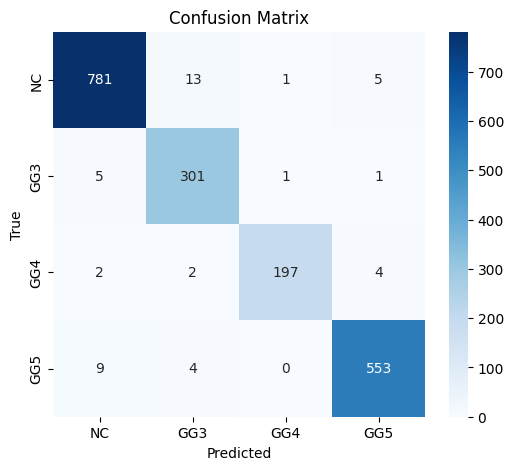

Classification Report:

              precision    recall  f1-score   support

          NC       0.98      0.98      0.98       800
         GG3       0.94      0.98      0.96       308
         GG4       0.99      0.96      0.98       205
         GG5       0.98      0.98      0.98       566

    accuracy                           0.97      1879
   macro avg       0.97      0.97      0.97      1879
weighted avg       0.98      0.97      0.98      1879



In [33]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Load best model ----
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ---- Compute accuracy ----
test_acc = (all_preds == all_labels).mean()
print(f"✅ Test Accuracy: {test_acc:.4f}")

# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_to_idx.keys(), yticklabels=label_to_idx.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---- Classification Report ----
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=label_to_idx.keys()))


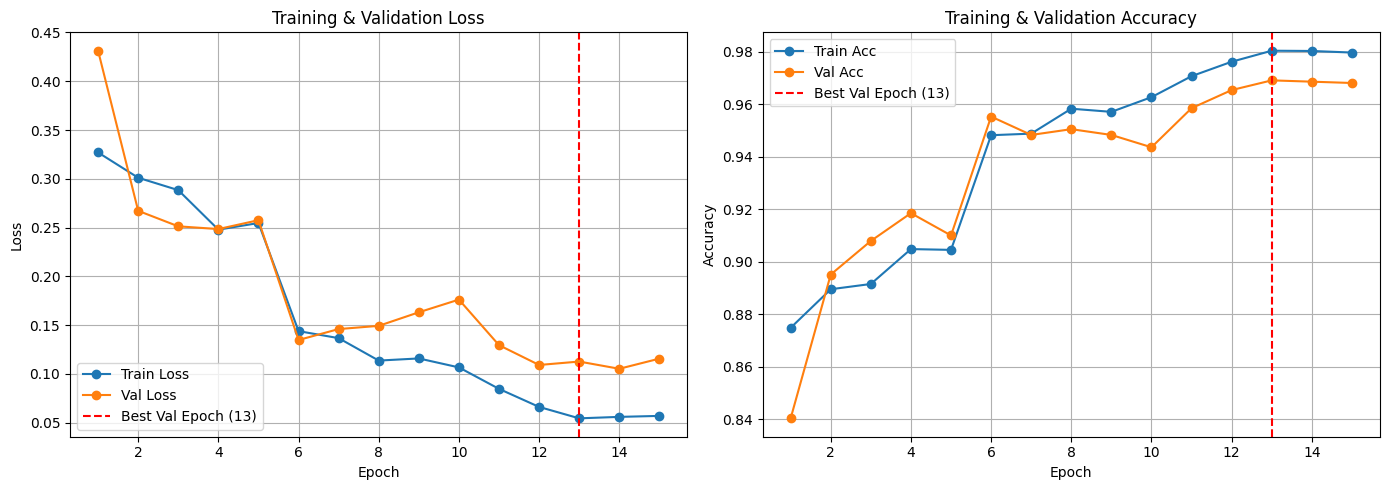

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Metrics from your training ----
train_losses = [0.3270, 0.3011, 0.2884, 0.2479, 0.2547, 0.1439, 0.1367, 0.1137, 0.1159, 0.1067, 0.0847, 0.0662, 0.0545, 0.0560, 0.0570]
val_losses   = [0.4313, 0.2672, 0.2513, 0.2485, 0.2576, 0.1348, 0.1460, 0.1493, 0.1632, 0.1762, 0.1295, 0.1092, 0.1127, 0.1053, 0.1157]
train_accs   = [0.8748, 0.8895, 0.8915, 0.9048, 0.9045, 0.9482, 0.9488, 0.9583, 0.9571, 0.9627, 0.9707, 0.9762, 0.9804, 0.9803, 0.9797]
val_accs     = [0.8403, 0.8951, 0.9079, 0.9185, 0.9100, 0.9553, 0.9483, 0.9505, 0.9483, 0.9436, 0.9585, 0.9654, 0.9691, 0.9686, 0.9681]

# ---- Best validation epoch ----
best_epoch = np.argmax(val_accs)
best_val_acc = val_accs[best_epoch]

# ---- Plot Loss ----
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(range(1,16), train_losses, label="Train Loss", marker='o')
plt.plot(range(1,16), val_losses, label="Val Loss", marker='o')
plt.axvline(best_epoch+1, color='r', linestyle='--', label=f"Best Val Epoch ({best_epoch+1})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

# ---- Plot Accuracy ----
plt.subplot(1,2,2)
plt.plot(range(1,16), train_accs, label="Train Acc", marker='o')
plt.plot(range(1,16), val_accs, label="Val Acc", marker='o')
plt.axvline(best_epoch+1, color='r', linestyle='--', label=f"Best Val Epoch ({best_epoch+1})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
